---
title: "Workshop for day 2"
author: "Inspired by Rasmus F Brøndum"
date: "23/05/2025"
format:
  html:
    toc: true
    toc-float: true
---


This document provides the basis for loading the data and training some dynamic classification models using Python libraries like `scikit-learn`, `xgboost`, and `optuna`.

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_score, average_precision_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier 
from sklearn.neural_network import MLPClassifier
import multiprocessing

np.random.seed(2025)
cores = multiprocessing.cpu_count()

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred_proba, class_names = ['0','1']):
    # 1. Convert probabilities to predicted class labels
    # We use np.argmax to find the index of the highest probability, which corresponds to the predicted class.
    y_pred = (y_pred_proba > 0.5).astype("int")

    # 2. Calculate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # 3. Create a figure and axes for the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # 4. Plot the confusion matrix using a heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14}) # Annotate cells with the integer counts

    # 5. Set labels, title, and ticks
    ax.set_xlabel('Predicted Labels', fontsize=12)
    ax.set_ylabel('True Labels', fontsize=12)
    ax.set_title('Confusion Matrix', fontsize=16)
    
    # Set tick labels font size
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Ensure the plot is displayed correctly
    plt.tight_layout()
    plt.show()
    
    # 6. Optional: Print a classification report for more detailed metrics
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

Load and read the data.

In [194]:
df = pd.read_csv("Data_ready_for_workshop2.csv")
df#['mevent_nyear'].value_counts()

,id,date,systolic,diastolic,erythrocytes,hemoglobin,wbc,platelets,glucose,potassium,...,diff_chol,diff_hdl,diff_ldl,diff_cvscore,diff_anxiety,diff_sleep,diff_alcohol,diff_fruit,diff_vegetable,mevent_nyear
0,2,2005-06-10 00:00:00+00:00,0.400000,0.39,0.469412,0.280624,0.034524,0.198358,0.114286,0.393617,...,0.521824,0.221029,0.463323,0.285809,0.50000,0.50000,0.500000,0.500000,0.500000,0
1,2,2006-09-12 00:00:00+00:00,0.282353,0.35,0.496471,0.296214,0.027381,0.165527,0.120408,0.425532,...,0.493658,0.281296,0.442285,0.305459,0.56383,0.60551,0.429909,0.420348,0.417636,0
2,2,2007-10-15 00:00:00+00:00,0.529412,0.35,0.508235,0.305122,0.036905,0.261286,0.124490,0.457447,...,0.519653,0.282340,0.509524,0.369324,0.62500,0.50000,0.500000,0.500000,0.500000,0
3,2,2008-09-22 00:00:00+00:00,0.529412,0.60,0.475294,0.271715,0.030952,0.246238,0.110204,0.404255,...,0.428825,0.242926,0.370860,0.358334,0.25000,0.37500,0.500000,0.625000,0.625000,0
4,2,2009-09-21 00:00:00+00:00,0.411765,0.45,0.447059,0.253898,0.035119,0.172367,0.120408,0.404255,...,0.349637,0.257616,0.279702,0.325703,0.50000,0.75000,0.500000,0.500000,0.375000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3904,1592,2007-06-09 00:00:00+00:00,0.364706,0.39,0.512941,0.314031,0.047024,0.363885,0.142857,0.000000,...,0.470249,0.262649,0.433082,0.337660,0.62500,0.62500,0.500000,0.500000,0.375000,0
3905,1593,2005-11-07 00:00:00+00:00,0.411765,0.55,0.556471,0.342984,0.051190,0.403557,0.226531,0.489362,...,0.577611,0.307042,0.558443,0.346020,0.50000,0.50000,0.500000,0.500000,0.500000,0
3906,1594,2005-10-03 00:00:00+00:00,0.470588,0.55,0.496471,0.298441,0.030952,0.184679,0.122449,0.500000,...,0.470076,0.275003,0.390023,0.369964,0.50000,0.50000,0.500000,0.500000,0.500000,0
3907,1595,2005-06-02 00:00:00+00:00,0.435294,0.47,0.556471,0.349666,0.038095,0.302326,0.126531,0.436170,...,0.550377,0.315279,0.548664,0.428717,0.50000,0.50000,0.500000,0.500000,0.500000,0


In [195]:
df_cal = df[df['split'] == 'calibration'].copy()
df = df[df['split'] != 'calibration'].copy()

df['split'] = pd.Categorical(df['split'], categories=['train', 'validation', 'test'], ordered=True)

df.sort_values('split', inplace=True)

split_counts = df['split'].value_counts()

# Prepare data
def prepare_data(data):
    X = data.drop(columns=['id', 'date', 'split', 'mevent_nyear'])
    y = LabelEncoder().fit_transform(data['mevent_nyear'])  
    return X, y

X, y = prepare_data(df)
X_cal, y_cal = prepare_data(df_cal)
X.reset_index(drop = True)
X_cal.reset_index(drop = True)

,systolic,diastolic,erythrocytes,hemoglobin,wbc,platelets,glucose,potassium,creatine,chol,...,diff_creatine,diff_chol,diff_hdl,diff_ldl,diff_cvscore,diff_anxiety,diff_sleep,diff_alcohol,diff_fruit,diff_vegetable
0,0.364706,0.45,0.614118,0.365256,0.045833,0.229822,0.161224,0.425532,0.130233,0.408844,...,0.325414,0.556490,0.234399,0.537060,0.322094,0.500,0.500,0.5,0.5,0.5
1,0.376471,0.37,0.590588,0.336303,0.047619,0.243502,0.132653,0.436170,0.146512,0.289116,...,0.361113,0.419138,0.285731,0.305411,0.321083,0.500,0.500,0.5,0.5,0.5
2,0.341176,0.35,0.591765,0.351893,0.059524,0.217510,0.165306,0.425532,0.127907,0.265986,...,0.349452,0.412512,0.343952,0.342346,0.322359,0.375,0.625,0.5,0.5,0.5
3,0.347059,0.35,0.576471,0.334076,0.042857,0.254446,0.146939,0.457447,0.137209,0.278912,...,0.369637,0.442797,0.286547,0.353722,0.339535,0.500,0.500,0.5,0.5,0.5
4,0.352941,0.43,0.569412,0.336303,0.039286,0.202462,0.163265,0.382979,0.139535,0.331973,...,0.377722,0.506020,0.341595,0.427562,0.363128,0.625,0.625,0.5,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,0.411765,0.55,0.592941,0.334076,0.042262,0.354309,0.093878,0.489362,0.216279,0.428571,...,0.411195,0.549103,0.208515,0.611735,0.321842,0.625,0.500,0.5,0.5,0.5
258,0.470588,0.45,0.631765,0.347439,0.041071,0.383037,0.097959,0.500000,0.267442,0.455782,...,0.467447,0.569389,0.273185,0.611936,0.343746,0.500,0.500,0.5,0.5,0.5
259,0.352941,0.45,0.591765,0.331849,0.037500,0.378933,0.097959,0.425532,0.183721,0.476190,...,0.350950,0.556498,0.253229,0.581765,0.335979,0.375,0.500,0.5,0.5,0.5
260,0.352941,0.45,0.627059,0.354120,0.039881,0.425445,0.100000,0.404255,0.190698,0.299320,...,0.365503,0.359895,0.255152,0.224194,0.322827,0.500,0.500,0.5,0.5,0.5


Data splitting

In [196]:

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=split_counts['test'], shuffle = False)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=split_counts['validation'], shuffle = False)

Basic Logistic Regression

Accuracy: 0.6596244131455399
ROC AUC: 0.6954436450839329
AP: 0.0523379587429463


c:\Users\kbg9\Documents\Python\python_venv\image_venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


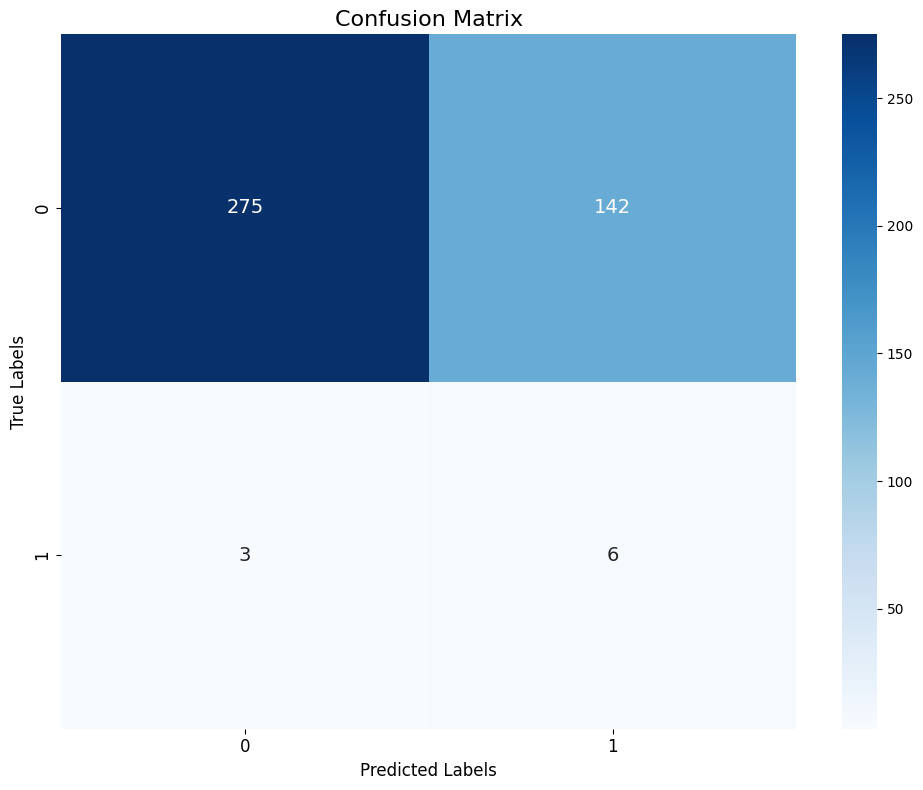

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.66      0.79       417
           1       0.04      0.67      0.08         9

    accuracy                           0.66       426
   macro avg       0.51      0.66      0.43       426
weighted avg       0.97      0.66      0.78       426



In [ ]:
blr_model = LogisticRegression(max_iter=1000, random_state=42) #, penalty='elasticnet', solver='saga', l1_ratio=0.4,class_weight='balanced'
blr_model.fit(X_train, y_train)
y_test_pred = blr_model.predict(X_test)
y_test_prob = blr_model.predict_proba(X_test)[:, 1]

print("Accuracy:", (y_test_pred == y_test).mean())
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("AP:", average_precision_score(y_test, y_test_prob))
plot_confusion_matrix(y_test, y_test_prob)



ROC Curve

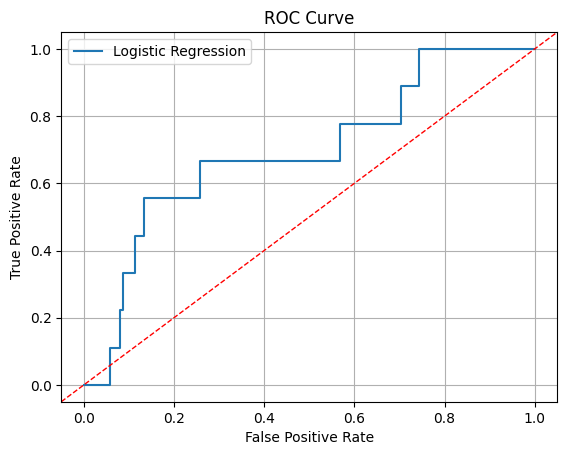

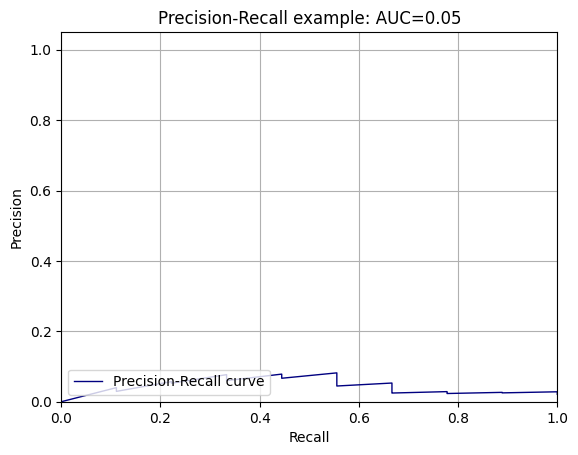

In [236]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.show()
plt.clf()


# Compute Precision-Recall and plot curve
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
average_precision = average_precision_score(y_test, y_test_prob)


# Plot Precision-Recall curve
plt.clf()
plt.plot(recall, precision, lw=1, color='navy',
         label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall example: AUC={0:0.2f}'.format(average_precision))
plt.legend(loc="lower left")
plt.grid()
plt.show()

Elastic Net Logistic Regression (Grid Search)

In [199]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit

param_grid = {
    'C': 1 / np.logspace(-4, 0, 101),  # Inverse of regularization
    'l1_ratio': np.linspace(0, 1, 11)
}

# Using `saga` solver for elastic net logistic regression
lr_model = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000)

test_fold = np.array([-1]*len(X_train) + [0]*len(X_val))

split = PredefinedSplit(test_fold)

lr_grid = GridSearchCV(
    lr_model,
    param_grid = {
        'C': 1 / np.logspace(-4, 0, 5),
        'l1_ratio': np.linspace(0, 1, 5)
    },
    scoring = 'average_precision', cv = split, verbose = 2, n_jobs = cores
)

lr_grid.fit(X_train_val, y_train_val)
print("Best parameters:", lr_grid.best_params_)

Fitting 1 folds for each of 25 candidates, totalling 25 fits


c:\Users\kbg9\Documents\Python\python_venv\image_venv\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'C': 1000.0, 'l1_ratio': 0.5}


ROC Curve

Accuracy: 0.9788732394366197
ROC AUC: 0.5528910205169197
AP: 0.03548146059879656


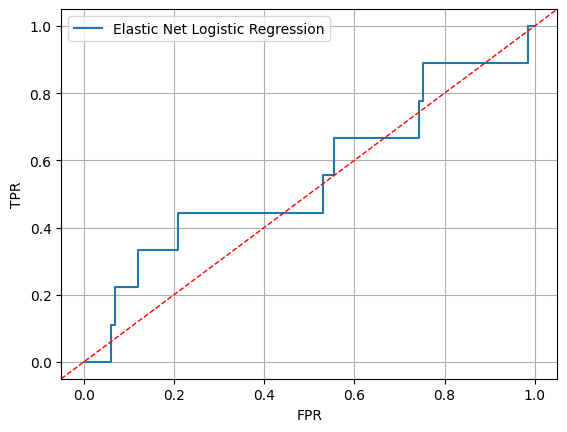

<Figure size 640x480 with 0 Axes>

In [200]:
lr_best = lr_grid.best_estimator_
y_test_prob = lr_best.predict_proba(X_test)[:, 1]

print("Accuracy:", (y_test_pred == y_test).mean())
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("AP:", average_precision_score(y_test, y_test_prob))
#plot_confusion_matrix(y_test, y_test_prob)

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='Elastic Net Logistic Regression')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Random Forest

In [201]:
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier(n_estimators=100, n_jobs=cores)

rf_grid = {
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

rf_search = RandomizedSearchCV(
    rf_model, rf_grid, n_iter=15, cv=split, scoring='average_precision', n_jobs=cores
)
rf_search.fit(X_train_val, y_train_val)
print("Best RF parameters:", rf_search.best_params_)

Best RF parameters: {'min_samples_leaf': 4, 'max_features': 'log2'}


ROC

Accuracy: 0.9788732394366197
ROC AUC: 0.6445510258459899
AP: 0.17577618307597057


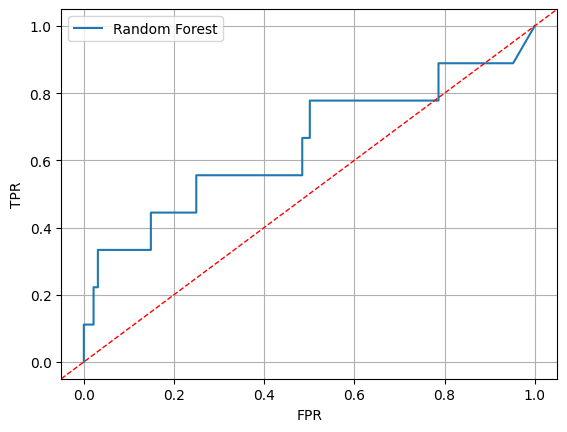

<Figure size 640x480 with 0 Axes>

In [202]:
rf_best = rf_search.best_estimator_
y_test_prob = rf_best.predict_proba(X_test)[:, 1]

print("Accuracy:", (y_test_pred == y_test).mean())
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("AP:", average_precision_score(y_test, y_test_prob))
#plot_confusion_matrix(y_test, y_test_prob)

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='Random Forest')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Gradient Boosted Trees (XGBoost)

In [203]:
gb_model = XGBClassifier(n_estimators=250, n_jobs=cores, eval_metric='logloss', random_state= 42)

gb_grid = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

gb_search = RandomizedSearchCV(
    gb_model, gb_grid, n_iter=25, scoring='average_precision', n_jobs=cores, cv=split
)
gb_search.fit(X_train_val, y_train_val)
print("Best GB parameters:", gb_search.best_params_)

Best GB parameters: {'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0}


ROC

Accuracy: 0.9788732394366197
ROC AUC: 0.6613375965893952
AP: 0.18516791220204867


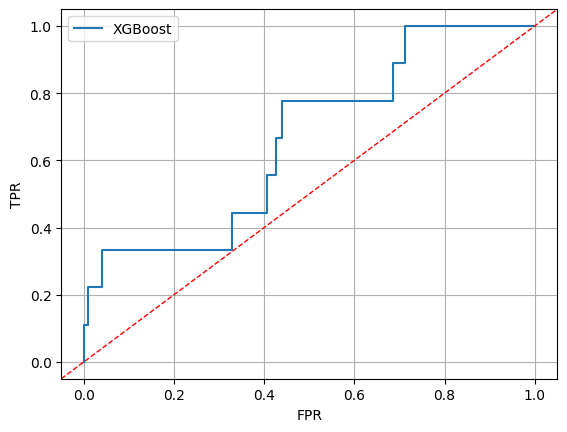

<Figure size 640x480 with 0 Axes>

In [204]:
gb_best = gb_search.best_estimator_
y_test_prob = gb_best.predict_proba(X_test)[:, 1]

print("Accuracy:", (y_test_pred == y_test).mean())
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("AP:", average_precision_score(y_test, y_test_prob))
#plot_confusion_matrix(y_test, y_test_prob)
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='XGBoost')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Multi-layer Perceptron (MLP)

In [205]:
mlp_grid = {
    'hidden_layer_sizes': [(10,), (30,), (50,)],
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

mlp_model = MLPClassifier(max_iter=1000, activation='logistic')

mlp_search = GridSearchCV(mlp_model, mlp_grid, scoring='average_precision', cv=split, n_jobs=cores)
mlp_search.fit(X_train_val, y_train_val)
print("Best MLP parameters:", mlp_search.best_params_)

Best MLP parameters: {'alpha': 1e-05, 'hidden_layer_sizes': (30,), 'learning_rate_init': 0.01}


ROC

Accuracy: 0.9788732394366197
ROC AUC: 0.6613375965893952
AP: 0.18516791220204867


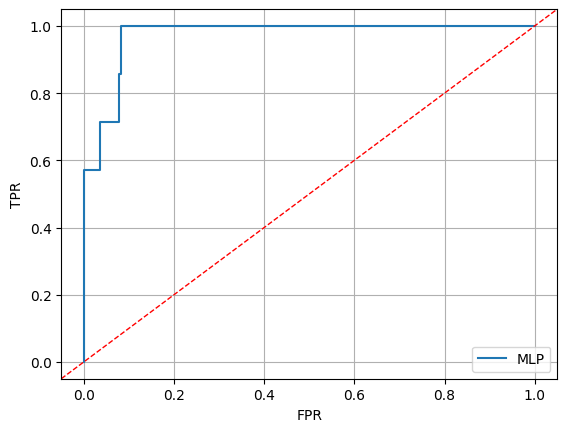

<Figure size 640x480 with 0 Axes>

In [206]:
mlp_best = mlp_search.best_estimator_
y_val_prob = mlp_best.predict_proba(X_val)[:, 1]


print("Accuracy:", (y_test_pred == y_test).mean())
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("AP:", average_precision_score(y_test, y_test_prob))
#plot_confusion_matrix(y_test, y_test_prob)

fpr, tpr, _ = roc_curve(y_val, y_val_prob)
plt.plot(fpr, tpr, label='MLP')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Final Evaluation on Test Set

In [207]:
models = {
    'Logistic Regression': blr_model,
    'Elastic Net': lr_best,
    'Random Forest': rf_best,
    'XGBoost': gb_best,
    'MLP': mlp_best
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"{name}")
    print("Precision:", precision_score(y_test, y_pred, zero_division = 0))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print("PR AUC:", average_precision_score(y_test, y_prob))
    print()

Logistic Regression
Precision: 0.0
ROC AUC: 0.7178257394084733
PR AUC: 0.06889162957215128

Elastic Net
Precision: 0.0
ROC AUC: 0.5528910205169197
PR AUC: 0.03548146059879656

Random Forest
Precision: 0.0
ROC AUC: 0.6445510258459899
PR AUC: 0.17577618307597057

XGBoost
Precision: 0.0
ROC AUC: 0.6613375965893952
PR AUC: 0.18516791220204867

MLP
Precision: 0.5
ROC AUC: 0.6887823074873434
PR AUC: 0.18007680497456005



Feature Importance (when applicable)

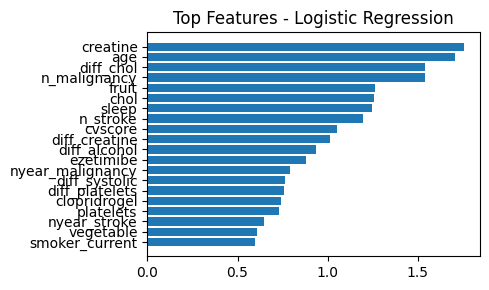

<Figure size 640x480 with 0 Axes>

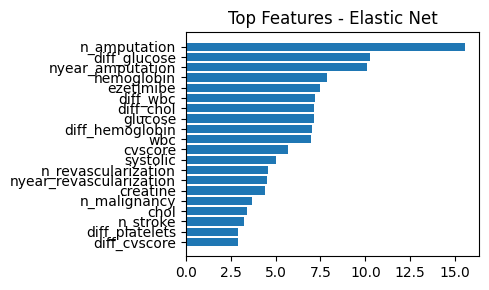

<Figure size 640x480 with 0 Axes>

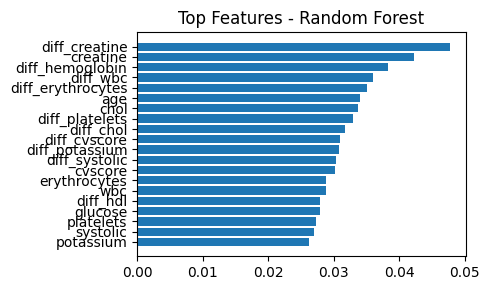

<Figure size 640x480 with 0 Axes>

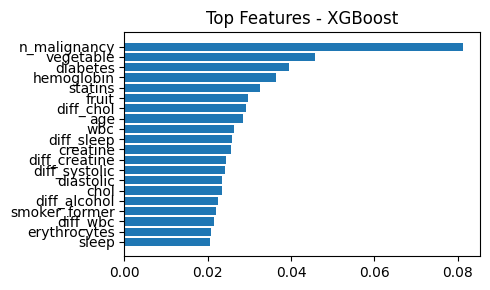

  0%|          | 0/10 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

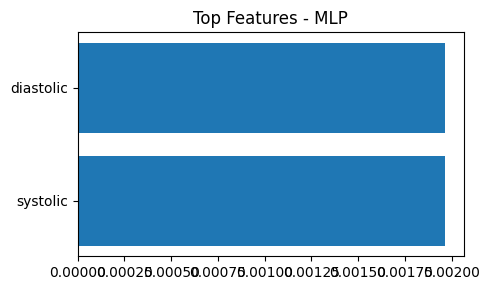

<Figure size 640x480 with 0 Axes>

In [208]:
from sklearn.inspection import permutation_importance
from itertools import chain
import shap
from sklearn.datasets import load_iris

for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif name in {'Elastic Net', 'Logistic Regression'}:
        importances = np.array(list(chain.from_iterable([abs(number) for number in model.coef_])))
    else:
        # Use KernelExplainer (model-agnostic)
        explainer = shap.KernelExplainer(model.predict_proba, X_train[:50], rng = 42)
        shap_values = explainer.shap_values(X_test[:10], rng = 42)  # smaller subset for speed
        shap_array = np.array(shap_values[1])
        importances = np.abs(shap_array).mean(axis=0)

    top_idx = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(5,3))
    plt.barh(np.array(X.columns)[top_idx], importances[top_idx])
    plt.title(f"Top Features - {name}")
    plt.tight_layout()
    plt.gca().invert_yaxis()
    plt.show()
    plt.clf()

# Model calibration 

In [209]:
df_cal

,id,date,systolic,diastolic,erythrocytes,hemoglobin,wbc,platelets,glucose,potassium,...,diff_chol,diff_hdl,diff_ldl,diff_cvscore,diff_anxiety,diff_sleep,diff_alcohol,diff_fruit,diff_vegetable,mevent_nyear
18,5,2005-05-19 00:00:00+00:00,0.364706,0.45,0.614118,0.365256,0.045833,0.229822,0.161224,0.425532,...,0.556490,0.234399,0.537060,0.322094,0.500,0.500,0.5,0.5,0.5,0
19,5,2006-09-13 00:00:00+00:00,0.376471,0.37,0.590588,0.336303,0.047619,0.243502,0.132653,0.436170,...,0.419138,0.285731,0.305411,0.321083,0.500,0.500,0.5,0.5,0.5,0
20,5,2007-10-08 00:00:00+00:00,0.341176,0.35,0.591765,0.351893,0.059524,0.217510,0.165306,0.425532,...,0.412512,0.343952,0.342346,0.322359,0.375,0.625,0.5,0.5,0.5,0
21,5,2008-09-24 00:00:00+00:00,0.347059,0.35,0.576471,0.334076,0.042857,0.254446,0.146939,0.457447,...,0.442797,0.286547,0.353722,0.339535,0.500,0.500,0.5,0.5,0.5,0
22,5,2009-09-30 00:00:00+00:00,0.352941,0.43,0.569412,0.336303,0.039286,0.202462,0.163265,0.382979,...,0.506020,0.341595,0.427562,0.363128,0.625,0.625,0.5,0.5,0.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,1435,2007-01-23 00:00:00+00:00,0.411765,0.55,0.592941,0.334076,0.042262,0.354309,0.093878,0.489362,...,0.549103,0.208515,0.611735,0.321842,0.625,0.500,0.5,0.5,0.5,0
3640,1435,2008-01-23 00:00:00+00:00,0.470588,0.45,0.631765,0.347439,0.041071,0.383037,0.097959,0.500000,...,0.569389,0.273185,0.611936,0.343746,0.500,0.500,0.5,0.5,0.5,0
3641,1435,2009-04-20 00:00:00+00:00,0.352941,0.45,0.591765,0.331849,0.037500,0.378933,0.097959,0.425532,...,0.556498,0.253229,0.581765,0.335979,0.375,0.500,0.5,0.5,0.5,0
3642,1435,2010-05-13 00:00:00+00:00,0.352941,0.45,0.627059,0.354120,0.039881,0.425445,0.100000,0.404255,...,0.359895,0.255152,0.224194,0.322827,0.500,0.500,0.5,0.5,0.5,0


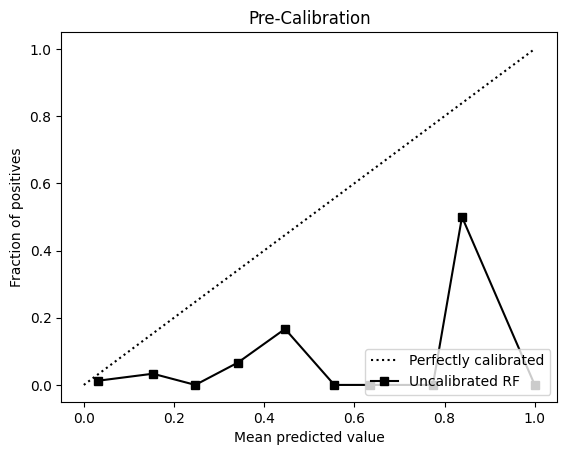

In [210]:
import scikitplot as skplt  # For better calibration plots
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# Train the random forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# --- Predictions for test and calibration sets ---
rf_test_proba = rf.predict_proba(X_test)[:, 1]

X_cal = df_cal.drop(columns=['mevent_nyear', 'id', 'date', 'split'])
y_cal = df_cal['mevent_nyear']
rf_cal_proba = rf.predict_proba(X_cal)[:, 1]

# --- Pre-Calibration Plot ---
skplt.metrics.plot_calibration_curve(
    y_test, [rf_test_proba], ['Uncalibrated RF'], n_bins=10
)
plt.title("Pre-Calibration")
plt.show()


Brier Score Comparison:
    Uncalibrated  Calibrated
0      0.021061    0.020483


c:\Users\kbg9\Documents\Python\python_venv\image_venv\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


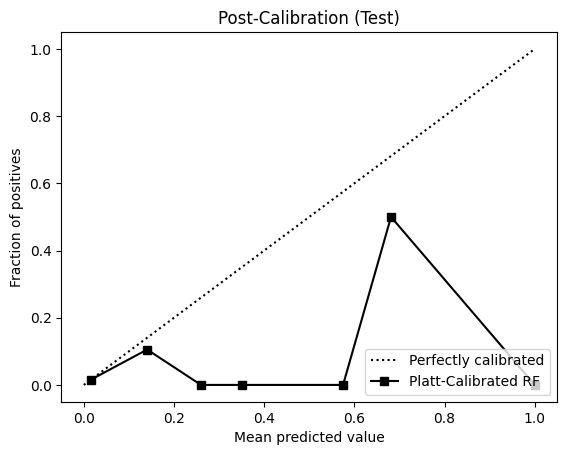

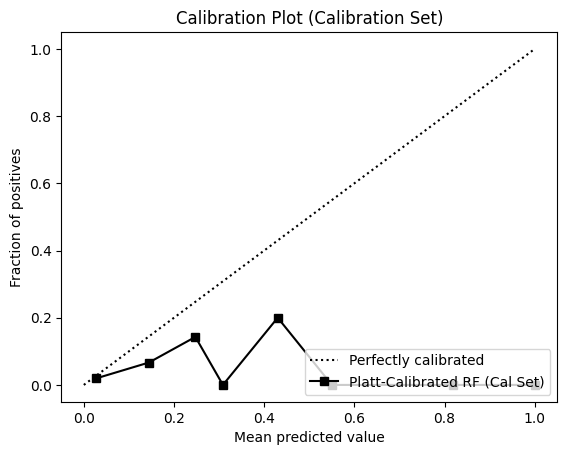

In [211]:
# --- Platt Scaling (Logistic Regression Calibration) ---
# Use Platt scaling only (sigmoid method)
platt_scaler = CalibratedClassifierCV(estimator=rf, method='sigmoid', cv='prefit')
platt_scaler.fit(X_cal, y_cal)

# Calibrated predictions
rf_platt_test = platt_scaler.predict_proba(X_test)[:, 1]
rf_platt_cal = platt_scaler.predict_proba(X_cal)[:, 1]

# --- Brier Scores ---
uncalibrated_brier = brier_score_loss(y_test, rf_test_proba)
calibrated_brier = brier_score_loss(y_test, rf_platt_test)

final_cal = pd.DataFrame({
    'Uncalibrated': [uncalibrated_brier],
    'Calibrated': [calibrated_brier]
})
print("Brier Score Comparison:\n", final_cal)

# --- Post-Calibration Plot (Test Set) ---
skplt.metrics.plot_calibration_curve(
    y_test, [rf_platt_test], ['Platt-Calibrated RF'], n_bins=10
)
plt.title("Post-Calibration (Test)")
plt.show()

# --- Calibration Plot (Calibration Set) ---
skplt.metrics.plot_calibration_curve(
    y_cal, [rf_platt_cal], ['Platt-Calibrated RF (Cal Set)'], n_bins=10
)
plt.title("Calibration Plot (Calibration Set)")
plt.show()